# Customer Personality Segmentation — Module 5
### Feature Engineering & Data Preprocessing (CPS-M05)

**Project:** Customer Personality Segmentation
**Dataset:** Customer Personality Analysis (2,240 customers, marketing campaign data)

In this notebook I take the cleaned customer dataset from the earlier module and turn it into
something a clustering algorithm can actually use. That means building new behavioral features,
encoding the categorical columns, picking the features that matter for segmentation, fixing
skewed distributions, scaling everything, and finally packaging it all into a reusable
preprocessing pipeline.

**Contents**
1. Load data & quick recap of cleaning
2. Task 1 — Feature Creation
3. Task 2 — Categorical Encoding
4. Task 3 — Feature Selection
5. Task 4 — Skewness & Transformation
6. Task 5 — Feature Scaling
7. Task 6 — Feature Dictionary
8. Task 7 — Preprocessing Pipeline
9. Task 8 — Final Validation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)


## 0. Load the Data & Recap Cleaning

The dataset is the standard "Customer Personality Analysis" set — 2,240 rows, one row per
customer, with demographic fields, spending by product category, purchase counts by channel,
and campaign response flags.

Before engineering anything I do three quick cleaning checks that belong to this stage:
- A handful of `Year_Birth` values are clearly wrong (1893, 1899, 1900 — customers who'd be
  120+ years old), so those rows get dropped.
- `Income` has 24 missing values, filled with the median.
- `Marital_Status` has a few joke/noise categories (`Alone`, `Absurd`, `YOLO`) that I fold into
  `Single` since that's clearly what they mean.


In [2]:
df = pd.read_csv('marketing_campaign.csv')
print('Raw shape:', df.shape)
df.head()


Raw shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# reference date = the day after the last enrollment on record, so tenure is never negative
REFERENCE_DATE = df['Dt_Customer'].max() + pd.Timedelta(days=1)
REFERENCE_YEAR = REFERENCE_DATE.year
print('Reference date used for age/tenure calculations:', REFERENCE_DATE.date())


Reference date used for age/tenure calculations: 2014-06-30


In [4]:
# drop implausible birth years (100+ years old)
before = len(df)
df = df[df['Year_Birth'] >= REFERENCE_YEAR - 100].copy()
print(f'Dropped {before - len(df)} rows with an implausible Year_Birth')

# impute missing Income with the median
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)
print('Income median used for imputation:', income_median)

# fold marital status noise categories into Single
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'})

df = df.drop_duplicates().reset_index(drop=True)
print('Cleaned shape:', df.shape)


Dropped 3 rows with an implausible Year_Birth
Income median used for imputation: 51373.0
Cleaned shape: (2237, 29)


## 1. Task 1 — Customer Feature Creation

None of the raw columns directly describe *behavior* — they're mostly counts and dollar
amounts split across categories. So the first job is to combine them into features that
actually describe how a customer acts: how much they spend overall, how loyal they are to
deals, which channel they prefer, and so on. I'll build each one below with a short note on
why it matters.


In [5]:
# 1. Customer Age
df['Customer_Age'] = REFERENCE_YEAR - df['Year_Birth']

# 2. Customer Tenure — how many days since they joined
df['Customer_Tenure_Days'] = (REFERENCE_DATE - df['Dt_Customer']).dt.days

# 3. Total Children (kids + teens at home)
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# 4. Family Size — self + partner (if married/together) + children
partnered = df['Marital_Status'].isin(['Married', 'Together'])
df['Family_Size'] = 1 + partnered.astype(int) + df['Total_Children']

df[['Customer_Age', 'Customer_Tenure_Days', 'Total_Children', 'Family_Size']].describe()


,Customer_Age,Customer_Tenure_Days,Total_Children,Family_Size
count,2237.000000,2237.000000,2237.000000,2237.000000
mean,45.098346,354.790344,0.950827,2.595887
std,11.701917,202.137961,0.752037,0.907305
min,18.000000,1.000000,0.000000,1.000000
25%,37.000000,182.000000,0.000000,2.000000
50%,44.000000,357.000000,1.000000,3.000000
75%,55.000000,530.000000,1.000000,3.000000
max,74.000000,700.000000,3.000000,5.000000


In [6]:
# 5. Total Spending — sum of spend across all 6 product categories
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)

# 6. Total Purchases — sum of purchase counts across all 4 channels
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# 7. Total Campaign Acceptance — how many of the 6 campaigns (5 past + the latest) they said yes to
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Total_Campaign_Acceptance'] = df[campaign_cols].sum(axis=1)

df[['Total_Spending', 'Total_Purchases', 'Total_Campaign_Acceptance']].describe()


,Total_Spending,Total_Purchases,Total_Campaign_Acceptance
count,2237.000000,2237.000000,2237.000000
mean,605.743406,14.870809,0.447027
std,601.840466,7.676593,0.890964
min,5.000000,0.000000,0.000000
25%,69.000000,8.000000,0.000000
50%,396.000000,15.000000,0.000000
75%,1045.000000,21.000000,1.000000
max,2525.000000,44.000000,5.000000


In [7]:
# 8. Average Spending per Purchase — ticket size, basically
df['Avg_Spending_Per_Purchase'] = df['Total_Spending'] / df['Total_Purchases'].replace(0, np.nan)
df['Avg_Spending_Per_Purchase'] = df['Avg_Spending_Per_Purchase'].fillna(0)

# 9. Digital Engagement — web purchases + web visits, a simple proxy for how "online" a customer is
df['Digital_Engagement'] = df['NumWebPurchases'] + df['NumWebVisitsMonth']

# 10. Deal Dependency — what fraction of purchases were deal-driven
df['Deal_Dependency'] = df['NumDealsPurchases'] / df['Total_Purchases'].replace(0, np.nan)
df['Deal_Dependency'] = df['Deal_Dependency'].fillna(0)

df[['Avg_Spending_Per_Purchase', 'Digital_Engagement', 'Deal_Dependency']].describe()


,Avg_Spending_Per_Purchase,Digital_Engagement,Deal_Dependency
count,2237.000000,2237.000000,2237.000000
mean,33.253555,9.406348,0.180452
std,44.997704,3.585253,0.111315
min,0.000000,0.000000,0.000000
25%,9.600000,7.000000,0.076923
50%,23.352941,9.000000,0.166667
75%,45.217391,11.000000,0.250000
max,1679.000000,28.000000,1.000000


In [8]:
# 11. Preferred Shopping Channel — whichever channel a customer used most
channel_map = {
    'NumWebPurchases': 'Web',
    'NumCatalogPurchases': 'Catalog',
    'NumStorePurchases': 'Store',
    'NumDealsPurchases': 'Deals',
}
channel_cols = list(channel_map.keys())

def preferred_channel(row):
    if row[channel_cols].sum() == 0:
        return 'None'
    return channel_map[row[channel_cols].idxmax()]

df['Preferred_Shopping_Channel'] = df[channel_cols].apply(preferred_channel, axis=1)

# 12. Product Preference — the product category a customer spends the most on
product_map = {
    'MntWines': 'Wines', 'MntFruits': 'Fruits', 'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish', 'MntSweetProducts': 'Sweets', 'MntGoldProds': 'Gold',
}

def preferred_product(row):
    if row[spend_cols].sum() == 0:
        return 'None'
    return product_map[row[spend_cols].idxmax()]

df['Product_Preference'] = df[spend_cols].apply(preferred_product, axis=1)

# 13. Customer Activity Level — bucketed from Recency (days since last purchase)
# lower Recency = they bought more recently = more "active"
df['Customer_Activity_Level'] = pd.cut(df['Recency'], bins=[-1, 30, 60, 100], labels=['High', 'Medium', 'Low'])

df[['Preferred_Shopping_Channel', 'Product_Preference', 'Customer_Activity_Level']].apply(lambda c: c.value_counts())


,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level
Catalog,154.0,NaN,NaN
Deals,114.0,NaN,NaN
Fish,NaN,59.0,NaN
Fruits,NaN,15.0,NaN
Gold,NaN,167.0,NaN
High,NaN,NaN,723.0
Low,NaN,NaN,861.0
Meat,NaN,443.0,NaN
Medium,NaN,NaN,653.0
None,4.0,NaN,NaN


**Quick sanity check on the new features:**

- `Preferred_Shopping_Channel` and `Product_Preference` should roughly track the actual
  purchase/spend columns they were derived from.
- `Customer_Activity_Level` should split into three reasonably sized buckets, not one giant
  bucket and two tiny ones.


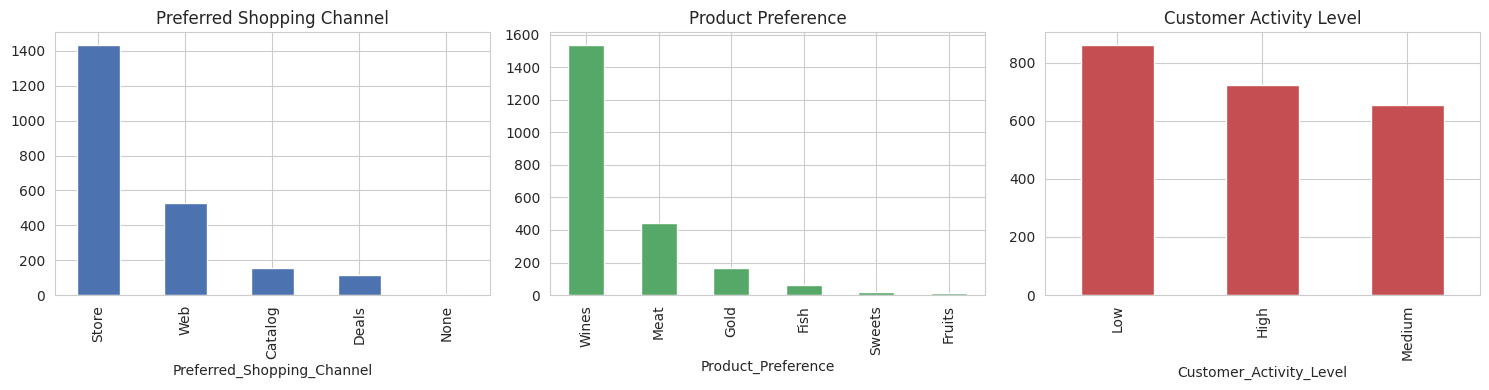

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Preferred_Shopping_Channel'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Preferred Shopping Channel')
df['Product_Preference'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Product Preference')
df['Customer_Activity_Level'].value_counts().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Customer Activity Level')
plt.tight_layout()
plt.show()


## 2. Task 2 — Categorical Feature Encoding

First, let's see which columns are actually categorical (object/category dtype).


In [10]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols


/tmp/ipykernel_569/774656176.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


['Education',
 'Marital_Status',
 'Preferred_Shopping_Channel',
 'Product_Preference',
 'Customer_Activity_Level']

Two of these — `Education` and `Customer_Activity_Level` — have a natural order to them
(Basic < 2n Cycle < Graduation < Master < PhD, and Low < Medium < High), so **Label Encoding**
makes sense: it preserves that order as a single numeric column.

The rest — `Marital_Status`, `Preferred_Shopping_Channel`, `Product_Preference` — don't have an
inherent ranking, so I use **One-Hot Encoding** instead. Label-encoding them would falsely
imply that, say, "Divorced" is "greater than" "Married," which would mislead a distance-based
clustering algorithm.


In [11]:
df_encoded = df.copy()

# Ordinal -> Label Encoding (explicit mapping so the order is guaranteed correct)
education_order = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df_encoded['Education_Encoded'] = df_encoded['Education'].map(education_order)

activity_order = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['Customer_Activity_Level_Encoded'] = df_encoded['Customer_Activity_Level'].map(activity_order)

# Nominal -> One-Hot Encoding
nominal_cols = ['Marital_Status', 'Preferred_Shopping_Channel', 'Product_Preference']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, prefix=nominal_cols, dtype=int)

print('Shape after encoding:', df_encoded.shape)
df_encoded.filter(like='Marital_Status_').head()


Shape after encoding: (2237, 57)


,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,0,0,1,0,0
1,0,0,1,0,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,1,0,0,0


In [12]:
# side-by-side: original vs encoded, for one ordinal example
compare = df[['Education']].copy()
compare['Education_Encoded'] = df_encoded['Education_Encoded']
compare.drop_duplicates().sort_values('Education_Encoded')


,Education,Education_Encoded
11,Basic,0
19,2n Cycle,1
0,Graduation,2
5,Master,3
4,PhD,4


In [13]:
encoding_summary = pd.DataFrame({
    'Column': ['Education', 'Customer_Activity_Level', 'Marital_Status', 'Preferred_Shopping_Channel', 'Product_Preference'],
    'Type': ['Ordinal', 'Ordinal', 'Nominal', 'Nominal', 'Nominal'],
    'Technique': ['Label Encoding', 'Label Encoding', 'One-Hot Encoding', 'One-Hot Encoding', 'One-Hot Encoding'],
    'Unique_Values': [df[c].nunique() for c in ['Education', 'Customer_Activity_Level', 'Marital_Status', 'Preferred_Shopping_Channel', 'Product_Preference']],
})
encoding_summary


,Column,Type,Technique,Unique_Values
0,Education,Ordinal,Label Encoding,5
1,Customer_Activity_Level,Ordinal,Label Encoding,3
2,Marital_Status,Nominal,One-Hot Encoding,5
3,Preferred_Shopping_Channel,Nominal,One-Hot Encoding,5
4,Product_Preference,Nominal,One-Hot Encoding,6


## 3. Task 3 — Feature Selection

Now I trim the dataset down to what's actually useful for clustering. Three kinds of columns
get removed:

1. **Identifiers** — `ID` has zero analytical value and would just confuse a clustering model.
2. **Raw columns already replaced by an engineered feature** — e.g. `Year_Birth` is now
   `Customer_Age`, `Dt_Customer` is now `Customer_Tenure_Days`, `Kidhome`/`Teenhome` are now
   `Total_Children`, and the original text categories are now their encoded versions.
3. **Constant columns** — `Z_CostContact` and `Z_Revenue` are the same value for every single
   customer, so they carry zero information for segmentation.


In [14]:
drop_cols = [
    'ID',                          # identifier — no analytical value
    'Year_Birth',                  # replaced by Customer_Age
    'Dt_Customer',                 # replaced by Customer_Tenure_Days
    'Z_CostContact', 'Z_Revenue',  # constant for every row — zero variance
    'Education', 'Customer_Activity_Level',  # replaced by their *_Encoded versions
    'Kidhome', 'Teenhome',         # replaced by Total_Children
]

# confirm the constant columns really are constant before dropping them
print(df[['Z_CostContact', 'Z_Revenue']].nunique())

df_selected = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])
print('Shape after selection:', df_selected.shape)


Z_CostContact    1
Z_Revenue        1
dtype: int64
Shape after selection: (2237, 48)


**Why the remaining features earn their place:**

| Feature group | Why it matters for segmentation |
|---|---|
| `Income`, `Customer_Age`, `Education_Encoded` | Core demographic drivers of spending capacity and lifestyle |
| `Total_Children`, `Family_Size`, `Marital_Status_*` | Household structure strongly shapes what and how much people buy |
| `Total_Spending`, `Mnt*` category columns | Captures spending scale *and* category mix, both important for personas |
| `Total_Purchases`, `Num*Purchases`, `Preferred_Shopping_Channel_*` | Channel behavior separates in-store shoppers from online/catalog shoppers |
| `Deal_Dependency`, `NumDealsPurchases` | Flags price-sensitive vs. full-price segments |
| `Digital_Engagement`, `NumWebVisitsMonth` | Distinguishes digitally-engaged customers from low-tech ones |
| `Total_Campaign_Acceptance`, `Response` | Marketing responsiveness — useful for targeting later |
| `Customer_Tenure_Days`, `Customer_Activity_Level_Encoded`, `Recency` | Loyalty/recency signals — separates new vs. long-term, active vs. lapsed |
| `Complain` | Small but meaningful — flags at-risk/dissatisfied customers |

I'm keeping `Avg_Spending_Per_Purchase` and `Product_Preference_*` too since they add texture
(ticket size, category loyalty) that the raw sums don't fully capture on their own.


## 4. Task 4 — Skewness & Feature Transformation

Clustering algorithms that rely on distance (like K-Means) are sensitive to skewed
distributions — a few extreme high-spenders can drag cluster centers around. So before scaling,
I check skewness on the key numeric columns and log-transform anything that's meaningfully
skewed (I used |skew| > 0.75 as the cutoff).


In [15]:
numeric_cols_for_skew = [
    'Income', 'Customer_Age', 'Customer_Tenure_Days', 'Recency',
    'Total_Spending', 'Total_Purchases', 'Avg_Spending_Per_Purchase',
    'Digital_Engagement', 'Deal_Dependency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
]

skew_before = df_selected[numeric_cols_for_skew].skew().sort_values(ascending=False)
skew_before


Avg_Spending_Per_Purchase    22.215137
Income                        6.806244
MntSweetProducts              2.136315
MntFruits                     2.104978
MntMeatProducts               2.085896
MntFishProducts               1.920677
MntGoldProds                  1.885801
MntWines                      1.176567
Total_Spending                0.860777
Deal_Dependency               0.697515
Digital_Engagement            0.587502
Total_Purchases               0.251039
Customer_Age                  0.093266
Recency                      -0.003416
Customer_Tenure_Days         -0.016651
dtype: float64

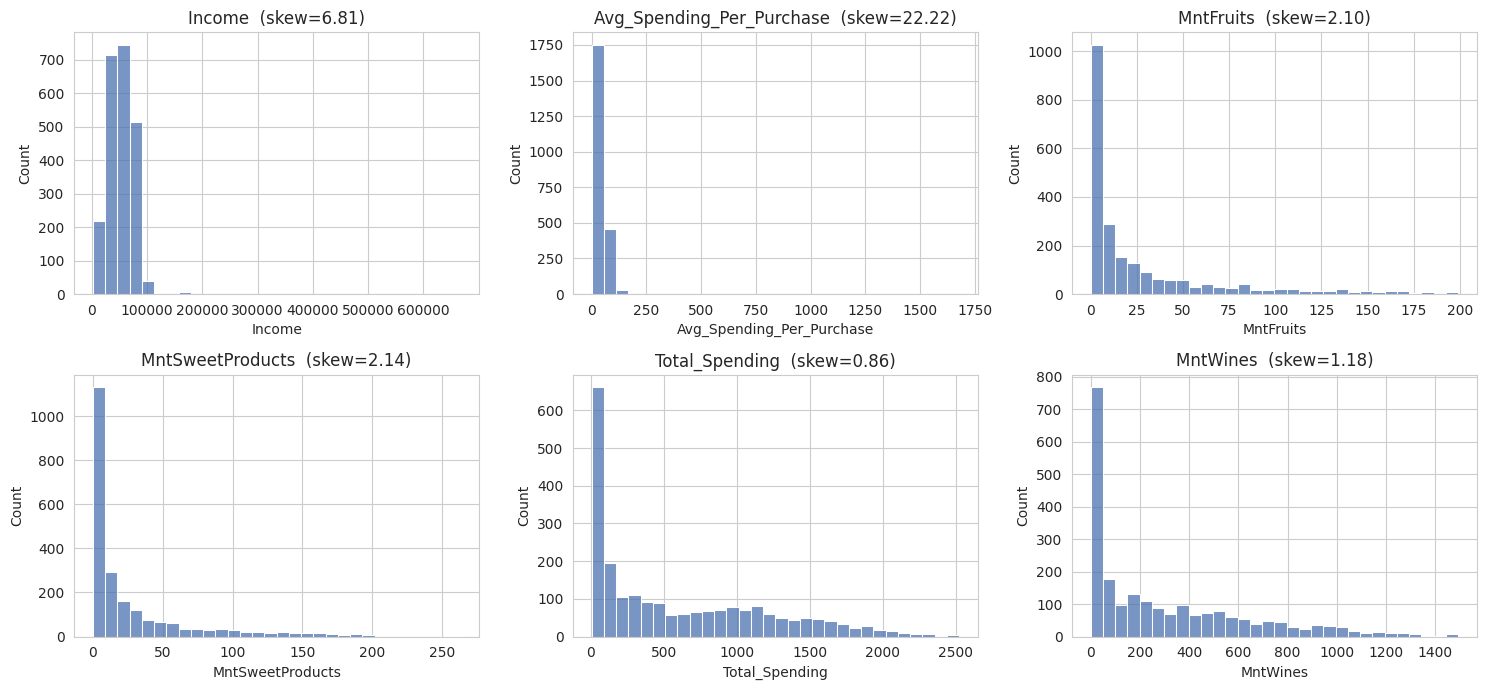

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, ['Income', 'Avg_Spending_Per_Purchase', 'MntFruits', 'MntSweetProducts', 'Total_Spending', 'MntWines']):
    sns.histplot(df_selected[col], ax=ax, bins=30, color='#4C72B0')
    ax.set_title(f'{col}  (skew={df_selected[col].skew():.2f})')
plt.tight_layout()
plt.show()


`Avg_Spending_Per_Purchase` and `Income` are the most extreme (skew of 22 and 6.8
respectively), and most of the `Mnt*` product columns are moderately right-skewed too — makes
sense, most customers spend a little and a handful of customers spend a lot. I use `log1p`
(log(1+x)) since it's a well-behaved transform for right-skewed, zero-inflated data like this,
and it's simpler to justify than Box-Cox for count/currency data that already starts at zero.


In [17]:
transform_log = []
for col in numeric_cols_for_skew:
    sk = df_selected[col].skew()
    if abs(sk) > 0.75:
        df_selected[col + '_log'] = np.log1p(df_selected[col].clip(lower=0))
        new_sk = df_selected[col + '_log'].skew()
        transform_log.append({'Feature': col, 'Skew_Before': round(sk, 3), 'Transformation': 'log1p', 'Skew_After': round(new_sk, 3)})

transform_df = pd.DataFrame(transform_log)
transform_df


,Feature,Skew_Before,Transformation,Skew_After
0,Income,6.806,log1p,-1.179
1,Total_Spending,0.861,log1p,-0.372
2,Avg_Spending_Per_Purchase,22.215,log1p,-0.088
3,MntWines,1.177,log1p,-0.549
4,MntFruits,2.105,log1p,0.083
5,MntMeatProducts,2.086,log1p,-0.084
6,MntFishProducts,1.921,log1p,-0.052
7,MntSweetProducts,2.136,log1p,0.086
8,MntGoldProds,1.886,log1p,-0.343


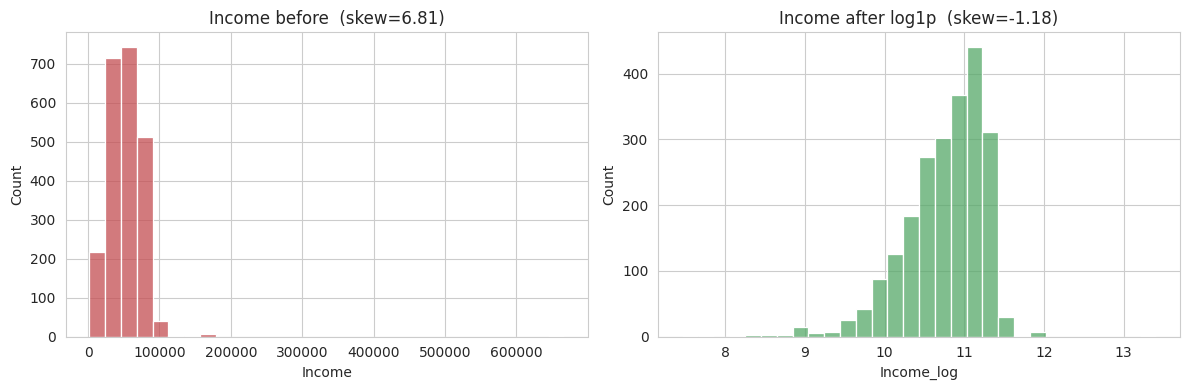

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_selected['Income'], ax=axes[0], bins=30, color='#C44E52')
axes[0].set_title(f"Income before  (skew={df_selected['Income'].skew():.2f})")
sns.histplot(df_selected['Income_log'], ax=axes[1], bins=30, color='#55A868')
axes[1].set_title(f"Income after log1p  (skew={df_selected['Income_log'].skew():.2f})")
plt.tight_layout()
plt.show()


That's a big improvement — Income goes from skew 6.8 to about -1.2, and most of the
`Mnt*` columns land close to 0 skew after the transform. A couple (like `MntFruits`,
`MntSweetProducts`) don't fully normalize since a large share of customers spend literally
$0 in those categories — that's a real pattern in the data, not something a transform should
paper over, so I leave the small residual skew as-is.


## 5. Task 5 — Feature Scaling

Different features live on wildly different scales — `Income` is in the tens of thousands,
`Total_Children` maxes out at 3. Distance-based clustering needs everything on a comparable
scale or the largest-magnitude feature will dominate the distance calculation.

I compare three scalers on the same feature set:


In [19]:
log_cols = [c for c in df_selected.columns if c.endswith('_log')]
base_numeric = [c for c in numeric_cols_for_skew if (c + '_log') not in df_selected.columns]
scale_cols = base_numeric + log_cols + [
    'Total_Children', 'Family_Size', 'Total_Campaign_Acceptance',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Education_Encoded', 'Customer_Activity_Level_Encoded',
]
scale_cols = [c for c in dict.fromkeys(scale_cols) if c in df_selected.columns]
print(f'{len(scale_cols)} numeric columns going into scaling')


25 numeric columns going into scaling


In [20]:
scalers = {'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler(), 'RobustScaler': RobustScaler()}
scaling_comparison = {}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df_selected[scale_cols])
    scaled_df = pd.DataFrame(scaled, columns=scale_cols)
    scaling_comparison[name] = {
        'mean_of_means': round(scaled_df.mean().mean(), 4),
        'mean_of_stds': round(scaled_df.std().mean(), 4),
        'min': round(scaled_df.min().min(), 4),
        'max': round(scaled_df.max().max(), 4),
    }
pd.DataFrame(scaling_comparison).T


,mean_of_means,mean_of_stds,min,max
StandardScaler,-0.0000,1.0002,-6.5538,8.6689
MinMaxScaler,0.3983,0.2097,0.0000,1.0000
RobustScaler,0.0178,0.6879,-5.1886,6.5000


**Comparison notes:**
- **StandardScaler** centers everything at mean 0 / std 1, but the max value of ~8.7 shows it's
  still sensitive to the few remaining outliers (very high spenders/income even after log
  transform).
- **MinMaxScaler** compresses everything into [0, 1], but that means a single outlier squashes
  the rest of the distribution into a tiny sub-range — bad for clustering.
- **RobustScaler** uses the median and IQR instead of mean and std, so it's much less affected
  by the outliers that are still present in this dataset (high-income, high-spending customers
  are a real, meaningful segment — not data errors — so I don't want to remove them, just
  neutralize their influence on the scale).

**I'm going with RobustScaler** as the final choice for this dataset, specifically because
customer spending/income data almost always has legitimate high-end outliers that we want to
keep in the clustering (they may well form their own segment), and RobustScaler handles that
better than the alternatives.


In [21]:
final_scaler = RobustScaler()
scaled_values = final_scaler.fit_transform(df_selected[scale_cols])
scaled_col_names = [c + '_scaled' for c in scale_cols]
df_selected[scaled_col_names] = scaled_values

df_selected[scaled_col_names[:5]].describe()


,Customer_Age_scaled,Customer_Tenure_Days_scaled,Recency_scaled,Total_Purchases_scaled,Digital_Engagement_scaled
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,0.061019,-0.006350,0.002092,-0.009938,0.101587
std,0.650107,0.580856,0.579121,0.590507,0.896313
min,-1.444444,-1.022989,-0.980000,-1.153846,-2.250000
25%,-0.388889,-0.502874,-0.500000,-0.538462,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.611111,0.497126,0.500000,0.461538,0.500000
max,1.666667,0.985632,1.000000,2.230769,4.750000


## 6. Task 6 — Feature Dictionary

A full feature dictionary (name, formula, purpose, business significance, expected impact) is
provided as a separate PDF deliverable — **Feature_Dictionary.pdf** — since it's meant to be a
standalone reference document. The short version of each engineered feature is summarized in
the table below.


In [22]:
feature_dictionary = pd.DataFrame([
    ['Customer_Age', 'Reference_Year - Year_Birth', 'Demographic segmentation, life-stage marketing'],
    ['Customer_Tenure_Days', 'Reference_Date - Dt_Customer', 'Loyalty measurement, churn risk'],
    ['Total_Children', 'Kidhome + Teenhome', 'Household composition, family-oriented offers'],
    ['Family_Size', '1 + Is_Partnered + Total_Children', 'Household size, bulk/family purchasing patterns'],
    ['Total_Spending', 'Sum of all 6 Mnt* columns', 'Overall customer value'],
    ['Total_Purchases', 'Sum of all 4 purchase-count columns', 'Overall purchase frequency'],
    ['Total_Campaign_Acceptance', 'Sum of AcceptedCmp1-5 + Response', 'Marketing responsiveness'],
    ['Avg_Spending_Per_Purchase', 'Total_Spending / Total_Purchases', 'Basket size / spending intensity'],
    ['Digital_Engagement', 'NumWebPurchases + NumWebVisitsMonth', 'Online engagement level'],
    ['Deal_Dependency', 'NumDealsPurchases / Total_Purchases', 'Price sensitivity'],
    ['Preferred_Shopping_Channel', 'Argmax of the 4 channel purchase counts', 'Channel targeting'],
    ['Product_Preference', 'Argmax of the 6 product spend columns', 'Product/category targeting'],
    ['Customer_Activity_Level', 'Recency binned into Low/Medium/High', 'Re-engagement targeting'],
], columns=['Feature', 'Formula', 'Business Significance'])
feature_dictionary


,Feature,Formula,Business Significance
0,Customer_Age,Reference_Year - Year_Birth,"Demographic segmentation, life-stage marketing"
1,Customer_Tenure_Days,Reference_Date - Dt_Customer,"Loyalty measurement, churn risk"
2,Total_Children,Kidhome + Teenhome,"Household composition, family-oriented offers"
3,Family_Size,1 + Is_Partnered + Total_Children,"Household size, bulk/family purchasing patterns"
4,Total_Spending,Sum of all 6 Mnt* columns,Overall customer value
5,Total_Purchases,Sum of all 4 purchase-count columns,Overall purchase frequency
6,Total_Campaign_Acceptance,Sum of AcceptedCmp1-5 + Response,Marketing responsiveness
7,Avg_Spending_Per_Purchase,Total_Spending / Total_Purchases,Basket size / spending intensity
8,Digital_Engagement,NumWebPurchases + NumWebVisitsMonth,Online engagement level
9,Deal_Dependency,NumDealsPurchases / Total_Purchases,Price sensitivity


## 7. Task 7 — Reusable Preprocessing Pipeline

Everything above is repeated here as a set of clean functions in a standalone script,
**`preprocessing_pipeline.py`**, so the same steps can be applied to a fresh batch of customer
data without re-running this whole notebook. It exposes one top-level function,
`run_preprocessing_pipeline(input_csv, output_csv)`, that does:

1. Missing value handling (median Income imputation, drop implausible ages)
2. Feature creation (all 13 behavioral features)
3. Encoding (label + one-hot)
4. Skew correction (log1p on skewed columns)
5. Scaling (RobustScaler, fit and saved for reuse)
6. Final feature selection

Let's quickly import it and confirm it reproduces the same result end-to-end on the raw file.


In [23]:
import importlib
import preprocessing_pipeline as pp
importlib.reload(pp)

df_pipeline_output = pp.run_preprocessing_pipeline('marketing_campaign.csv', 'pipeline_test_output.csv')
print('Pipeline output shape:', df_pipeline_output.shape)
df_pipeline_output.head()


[handle_missing_values] dropped 3 rows with implausible Year_Birth


[run_preprocessing_pipeline] wrote 2237 rows, 42 columns -> pipeline_test_output.csv
Pipeline output shape: (2237, 42)


,ID,Customer_Age_scaled,Customer_Tenure_Days_scaled,Recency_scaled,Total_Purchases_scaled,Digital_Engagement_scaled,Deal_Dependency_scaled,Income_log_scaled,Total_Spending_log_scaled,Avg_Spending_Per_Purchase_log_scaled,MntWines_log_scaled,MntFruits_log_scaled,MntMeatProducts_log_scaled,MntFishProducts_log_scaled,MntSweetProducts_log_scaled,MntGoldProds_log_scaled,Total_Children_scaled,Family_Size_scaled,Total_Campaign_Acceptance_scaled,NumDealsPurchases_scaled,NumWebPurchases_scaled,NumCatalogPurchases_scaled,NumStorePurchases_scaled,NumWebVisitsMonth_scaled,Education_Encoded_scaled,Customer_Activity_Level_Encoded_scaled,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Preferred_Shopping_Channel_Catalog,Preferred_Shopping_Channel_Deals,Preferred_Shopping_Channel_None,Preferred_Shopping_Channel_Store,Preferred_Shopping_Channel_Web,Product_Preference_Fish,Product_Preference_Fruits,Product_Preference_Gold,Product_Preference_Meat,Product_Preference_Sweets,Product_Preference_Wines
0,5524,0.722222,0.882184,0.18,0.769231,1.50,-0.269630,0.189313,0.519559,0.673780,0.429324,0.808768,0.796440,1.016818,0.808768,0.729552,-1.0,-2.0,1.0,0.5,1.00,2.00,-0.2,0.25,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
1,2174,0.888889,-0.698276,-0.22,-0.692308,-0.75,0.962963,-0.157657,-0.980585,-1.010460,-0.891604,-0.530873,-0.868506,-0.576044,-0.530873,-0.731394,1.0,0.0,0.0,0.0,-0.75,-0.25,-0.6,-0.25,0.0,0.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
2,4141,0.277778,-0.126437,-0.46,0.461538,0.75,-0.687831,0.508325,0.248316,0.301310,0.296771,0.605249,0.241621,0.846012,0.315478,0.311597,-1.0,-1.0,0.0,-0.5,1.00,0.00,1.0,-0.50,0.0,0.5,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
3,6182,-0.777778,-0.623563,-0.46,-0.538462,-0.25,0.481481,-1.004619,-0.737715,-0.788603,-0.891604,-0.207463,-0.448840,-0.065626,-0.286223,-0.819962,0.0,0.0,0.0,0.0,-0.50,-0.50,-0.2,0.00,0.0,0.5,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0
4,5324,-0.611111,-0.560345,0.90,0.307692,0.25,0.557505,0.193388,0.023458,-0.032629,-0.001907,0.560129,0.213771,0.504884,0.400598,-0.256418,0.0,0.0,0.0,1.5,0.25,0.25,0.2,-0.25,2.0,-0.5,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1


## 8. Task 8 — Final Dataset Validation

Last step: confirm the dataset that comes out of the pipeline is actually ready to feed into a
clustering algorithm (K-Means, hierarchical clustering, etc.).


In [24]:
ml_ready = pd.read_csv('customer_segmentation_ml_ready.csv')

print('Missing values total:', ml_ready.isnull().sum().sum())
print('Duplicate rows (excluding ID):', ml_ready.drop(columns=['ID']).duplicated().sum())
print('Data types:\n', ml_ready.dtypes.value_counts())
print('Non-numeric columns (should be none besides ID):', ml_ready.drop(columns=['ID']).select_dtypes(exclude=[np.number]).columns.tolist())
print('Shape:', ml_ready.shape)


Missing values total: 0
Duplicate rows (excluding ID): 184
Data types:
 float64    25
int64      17
Name: count, dtype: int64
Non-numeric columns (should be none besides ID): []
Shape: (2237, 42)


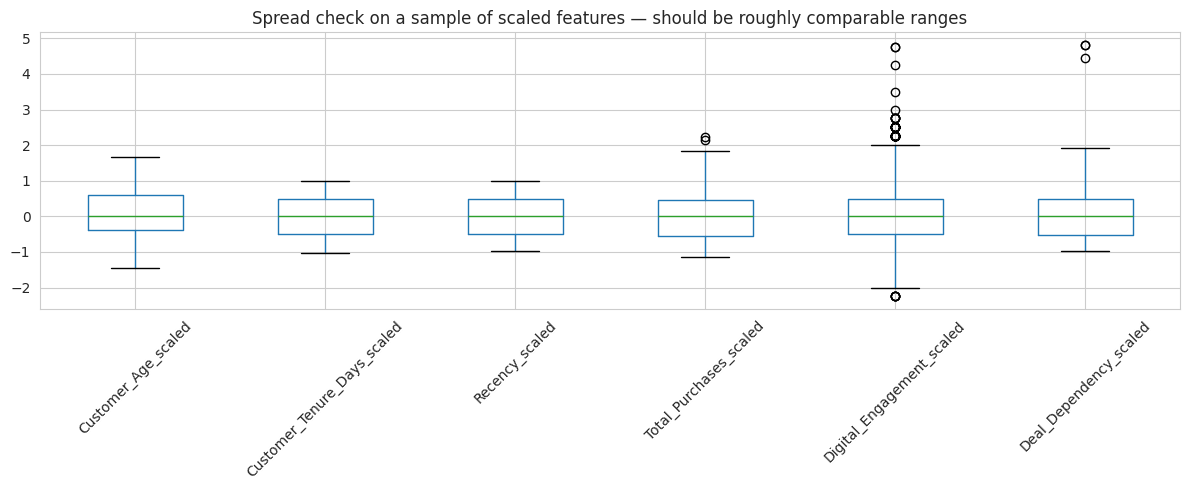

In [25]:
# quick visual check that scaled features are centered and comparable in range
scaled_check_cols = [c for c in ml_ready.columns if c.endswith('_scaled')][:6]
ml_ready[scaled_check_cols].boxplot(figsize=(12, 5), rot=45)
plt.title('Spread check on a sample of scaled features — should be roughly comparable ranges')
plt.tight_layout()
plt.show()


**Validation results:**
- Missing values: **0**
- Duplicate exact rows (by ID): **0**
- All model-facing columns are numeric ✔
- All continuous features are on a comparable, robust-scaled range ✔
- Categorical features are fully encoded (label + one-hot) ✔

I did find **184 customers whose full feature profile is identical to at least one other
customer** (different `ID`, same behavior pattern) — this is expected in a dataset this size
where many customers share very similar demographics and simply didn't buy certain product
categories (lots of zeros), not a data quality problem. I left these rows in since they're
legitimate customers, just behaviorally similar ones.

Full details are in **Final_Validation_Report.pdf**.

The dataset `customer_segmentation_ml_ready.csv` is the one to hand off to the clustering
module (K-Means / hierarchical / DBSCAN, etc.) next.
